# Анализ пользовательского спроса сервиса покупки билетов на мероприятия

## Цель:
выявить причины роста пользовательской активности сервиса покупки билетов.

## Задачи:

1. Проанализировать аудиторию сервиса.
2. Выявить популярные события, организаторов и площадки.
3. Сравнить активность пользователей в зависимости от устройств.



## Описание данных

Датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных:
* order_id — уникальный идентификатор заказа.
* user_id — уникальный идентификатор пользователя.
* created_dt_msk — дата создания заказа (московское время).
* created_ts_msk — дата и время создания заказа (московское время).
* event_id — идентификатор мероприятия из таблицы events.
* cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
* age_limit — возрастное ограничение мероприятия.
* currency_code — валюта оплаты, например rub для российских рублей.
* device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
* revenue — выручка от заказа.
* service_name — название билетного оператора.
* tickets_count — количество купленных билетов.
* total — общая сумма заказа.
* days_since_prev - количество дней с предыдущей покупки для каждого пользователя.

Датасет `final_tickets_events_df` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия:
* event_id — уникальный идентификатор мероприятия.
* event_name — название мероприятия.
* event_type_description — описание типа мероприятия.
* event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
* organizers — организаторы мероприятия.
* region_name — название региона.
* city_name — название города.
* venue_id — уникальный идентификатор площадки.
* venue_name — название площадки.
* venue_address — адрес площадки.

Датасет `final_tickets_tenge_df.csv` содержит информацию о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге:
* nominal — номинал (100 тенге).
* data — дата.
* curs — курс тенге к рублю.
* cdx — обозначение валюты (kzt).

## 1. Загрузка данных и знакомство с ними

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [55]:
orders_df = pd.read_csv('final_tickets_orders_df.csv')
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [56]:
orders_df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [57]:
# Перевод столбцов в тип datetime
orders_df['created_dt_msk'] = pd.to_datetime(orders_df['created_dt_msk'])
orders_df['created_ts_msk'] = pd.to_datetime(orders_df['created_ts_msk'])
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               290849 non-null  int64         
 1   user_id                290849 non-null  object        
 2   created_dt_msk         290849 non-null  datetime64[ns]
 3   created_ts_msk         290849 non-null  datetime64[ns]
 4   event_id               290849 non-null  int64         
 5   cinema_circuit         290849 non-null  object        
 6   age_limit              290849 non-null  int64         
 7   currency_code          290849 non-null  object        
 8   device_type_canonical  290849 non-null  object        
 9   revenue                290849 non-null  float64       
 10  service_name           290849 non-null  object        
 11  tickets_count          290849 non-null  int64         
 12  total                  290849 non-null  floa

In [58]:
# Проверка временного периода
orders_df['created_dt_msk'].min(), orders_df['created_dt_msk'].max()

(Timestamp('2024-06-01 00:00:00'), Timestamp('2024-10-31 00:00:00'))

In [59]:
events_df = pd.read_csv('final_tickets_events_df.csv')
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [60]:
events_df.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [61]:
tenge_df = pd.read_csv('final_tickets_tenge_df.csv')
tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [62]:
tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [63]:
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

## 2. Предобработка данных

In [10]:
# Категориальные признаки
print("orders_df['device_type_canonical'] :", orders_df['device_type_canonical'].unique())
print("events_df['event_type_main'] :", events_df['event_type_main'].unique())

orders_df['device_type_canonical'] : ['mobile' 'desktop']
events_df['event_type_main'] : ['театр' 'концерты' 'ёлки' 'другое' 'стендап' 'выставки' 'спорт']


In [64]:
# Проверка на пропуски
print(orders_df.isna().sum())
print(events_df.isna().sum())
print(tenge_df.isna().sum())

order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64
event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64
data       0
nominal    0
curs       0
cdx        0
dtype: int64


Пропуски присутствуют только в столбце `days_since_prev` в таблице `orders_df`. Это связано с тем, что для первый заказов пользователей отсутствует информация о предыдущем заказе. В остальных столбцах пропусков нет.

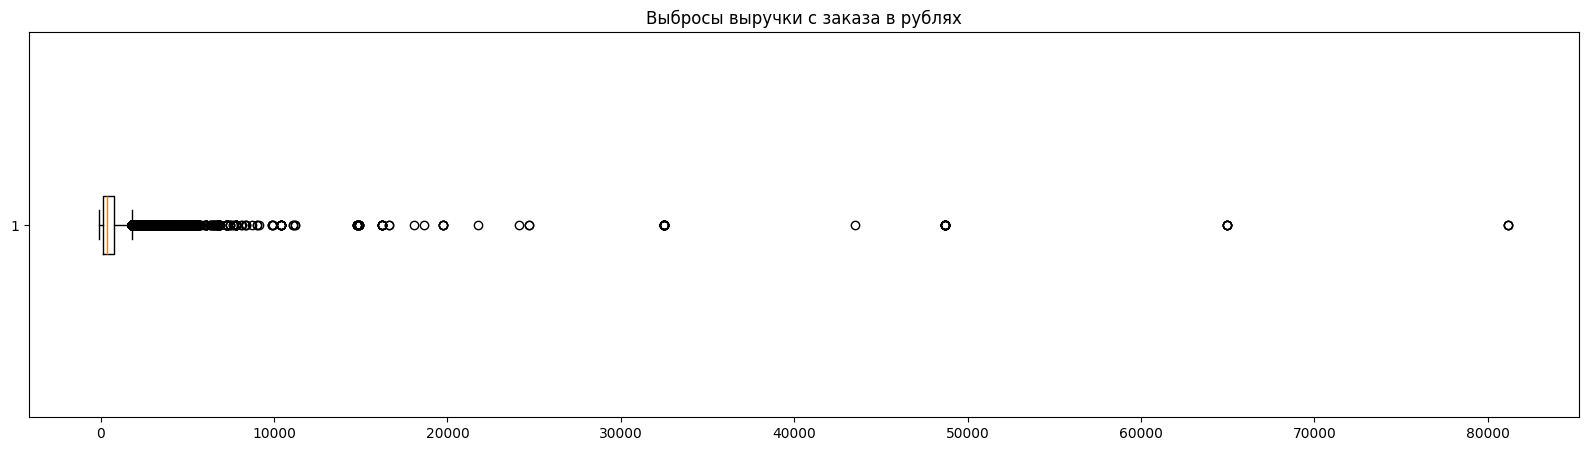

In [65]:
# Проверим наличие выбросов в столбце revenue
revenue_rub = orders_df[orders_df['currency_code'] == 'rub']['revenue']
plt.figure(figsize=(20, 5))
plt.boxplot(revenue_rub, orientation='horizontal')
plt.title('Выбросы выручки с заказа в рублях')
plt.show()

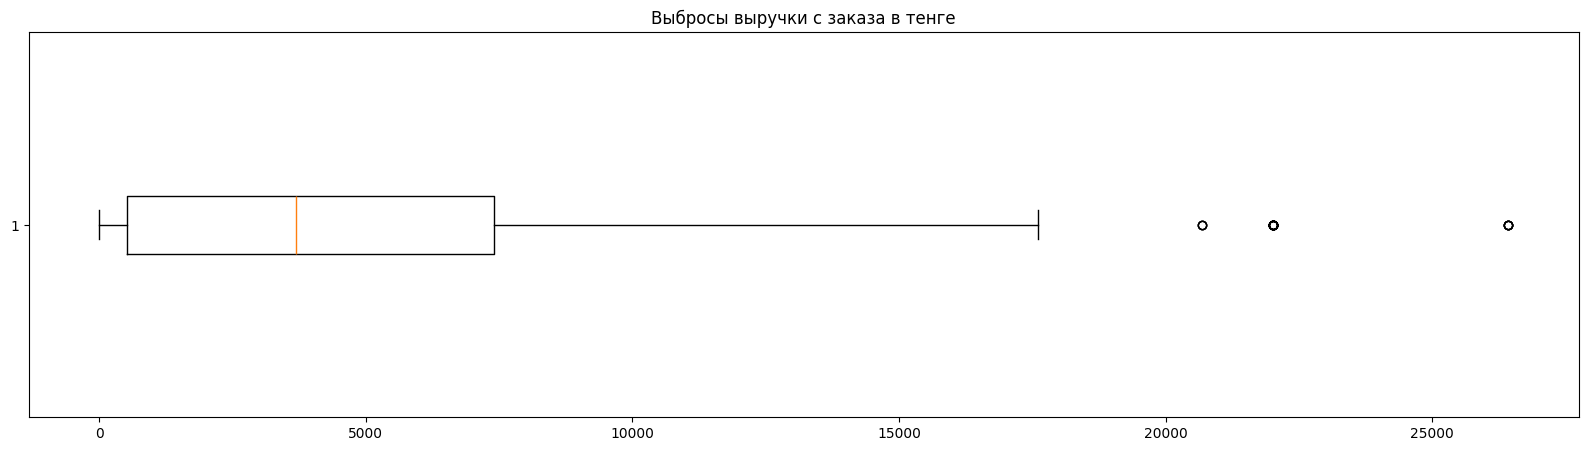

In [66]:
revenue_kzt = orders_df[orders_df['currency_code'] == 'kzt']['revenue']
plt.figure(figsize=(20, 5))
plt.boxplot(revenue_kzt, orientation='horizontal')
plt.title('Выбросы выручки с заказа в тенге')
plt.show()

In [67]:
upperbound_rub = revenue_rub.quantile(0.99)
upperbound_kzt = revenue_kzt.quantile(0.99)
print('99-й процентиль RUB:', upperbound_rub)
print('99-й процентиль KZT:', upperbound_kzt)
before = len(orders_df)
orders_df = orders_df[~(((orders_df['currency_code'] == 'rub') & (orders_df['revenue'] > upperbound_rub)) 
                        | 
                        ((orders_df['currency_code'] == 'kzt') & (orders_df['revenue'] > upperbound_kzt)))]
after = len(orders_df)
print('Удалено:', before - after)
print('Осталось:', after)

99-й процентиль RUB: 2569.5942000000005
99-й процентиль KZT: 17617.24
Удалено: 2887
Осталось: 287962


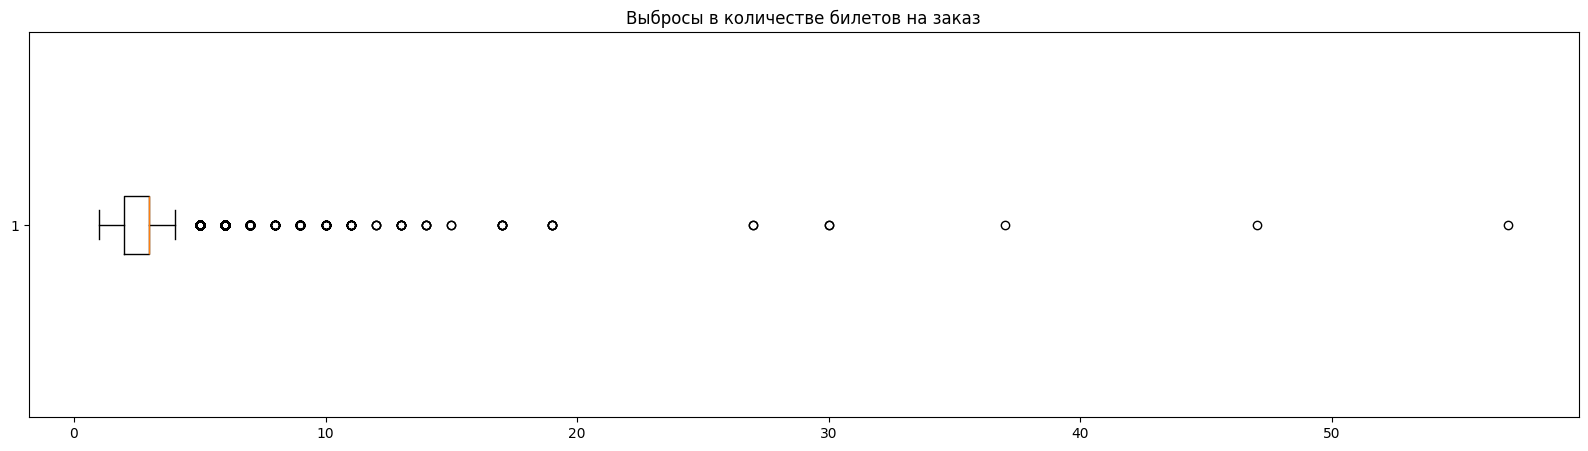

In [68]:
# Проверка на выбросы в tickets-count
plt.figure(figsize=(20, 5))
plt.boxplot(orders_df['tickets_count'], orientation='horizontal')
plt.title('Выбросы в количестве билетов на заказ')
plt.show()

In [15]:
upperbound_ticket = orders_df['tickets_count'].quantile(0.99)
orders_df = orders_df[orders_df['tickets_count'] < upperbound_ticket]

**Вывод**: в столбце `revenue` присутствуют значительные выбросы (особенно в рублях). Также выбросы присутствуют в столбце `tickets_cont`. Было принято решение отфильтровать по 99-перцентилю, чтобы не потерять действительно большие по выручке и количеству билетов заказы.

In [ ]:
# Проверка на дубликаты

duplicates = orders_df[orders_df.duplicated(subset=['user_id', 'created_ts_msk', 'event_id', 'device_type_canonical', 'revenue', 'tickets_count'], keep=False)]
duplicates

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
26894,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,Лови билет!,3,19450.63,11.0
26896,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,Лови билет!,3,19450.63,0.0
53715,1935113,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,Билеты в руки,2,6016.94,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285615,8548012,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,Билеты без проблем,4,14660.31,0.0
285617,8548041,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:50,489843,нет,18,rub,desktop,989.57,Билеты без проблем,3,10995.23,0.0
285618,8548070,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:50,489843,нет,18,rub,desktop,989.57,Билеты без проблем,3,10995.23,0.0
285619,8548099,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.57,Билеты без проблем,3,10995.23,0.0


Наблюдение: некоторые заказы дублируются неявно (совпадает пользователь, время заказа, количество билетов, выручка и событие). Скорее всего это вызвано технической ошибкой (один и тот же заказ выгрузился несколько раз). Такие дубликаты следует удалить.

In [69]:
before = len(orders_df)
orders_df = orders_df.drop_duplicates(subset=['user_id', 'created_ts_msk', 'event_id', 'device_type_canonical', 'revenue', 'tickets_count'])
after = len(orders_df)
print('Удалено дубликатов:', before - after)

Удалено дубликатов: 39


Для последующих рассчётов создадим дополнительные столбцы

In [70]:
orders_df = orders_df.merge(tenge_df[['data', 'curs']], how='left', left_on='created_dt_msk', right_on='data')
orders_df = orders_df.merge(events_df, how='left', on='event_id')

В заказах присутствуют две валюты — RUB и KZT. Для сопоставления выручки данные в тенге будут конвертированы в рубли по дневному курсу.

In [71]:
# Выручка в рублях
orders_df['revenue_rub'] = np.where(orders_df['currency_code'] == 'rub', orders_df['revenue'], orders_df['revenue'] * orders_df['curs'] / 100)
orders_df[orders_df['currency_code'] == 'kzt']

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub
73,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.10,...,событие,другое,№5088,Верхоречная область,Серебрянка,163.0,1533.0,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",98.503762
91,8634925,0040e12d70fae81,2024-09-02,2024-09-02 19:49:14,559476,нет,6,kzt,desktop,347.18,...,событие,другое,№5088,Верхоречная область,Серебрянка,163.0,1533.0,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",65.731589
98,7625522,0054b38b2653e6e,2024-09-09,2024-09-09 18:06:04,559582,нет,6,kzt,mobile,328.77,...,событие,другое,№5088,Верхоречная область,Серебрянка,163.0,1533.0,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",61.148261
465,5227657,01370a0e9c1a7d5,2024-06-04,2024-06-04 13:28:17,533803,нет,16,kzt,desktop,7397.66,...,фестиваль,концерты,№4950,Шанырский регион,Широковка,162.0,3407.0,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",1478.296591
466,2229782,01370a0e9c1a7d5,2024-06-04,2024-06-04 13:17:35,533803,нет,16,kzt,mobile,3698.83,...,фестиваль,концерты,№4950,Шанырский регион,Широковка,162.0,3407.0,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",739.148295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287796,6862648,ffc24188a1d58f2,2024-07-11,2024-07-11 12:39:48,538828,нет,12,kzt,mobile,4735.52,...,концерт,концерты,№2434,Верхоречная область,Серебрянка,163.0,4348.0,"Мастерская живого действия ""Юность"" Лтд","наб. Осенняя, д. 376",865.359454
287797,6763294,ffc24188a1d58f2,2024-09-05,2024-09-05 12:07:00,538828,нет,12,kzt,mobile,4735.52,...,концерт,концерты,№2434,Верхоречная область,Серебрянка,163.0,4348.0,"Мастерская живого действия ""Юность"" Лтд","наб. Осенняя, д. 376",872.363288
287798,3984021,ffc24188a1d58f2,2024-09-06,2024-09-06 19:20:03,533803,нет,16,kzt,mobile,1849.41,...,фестиваль,концерты,№4950,Шанырский регион,Широковка,162.0,3407.0,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",343.072953
287800,8493869,ffc4133fbba20f4,2024-06-21,2024-06-21 14:04:34,533803,нет,16,kzt,mobile,3698.83,...,фестиваль,концерты,№4950,Шанырский регион,Широковка,162.0,3407.0,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",687.209325


In [72]:
# Выручка с продажи одного билета
orders_df['one_ticket_revenue_rub'] = orders_df['revenue_rub'] / orders_df['tickets_count']

In [73]:
# Месяц заказа
orders_df['month'] = orders_df['created_dt_msk'].dt.month
orders_df.head()


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1521.94,380.4850,8
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",289.45,144.7250,7
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,№1540,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.57,314.6425,10
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",8.49,4.2450,7
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,№832,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.41,463.4700,10


In [74]:
# Сезон заказа
season = {
    1: 'зима', 2: 'зима', 3: 'весна', 4: 'весна', 5: 'весна', 6: 'лето', 7: 'лето', 8: 'лето', 9: 'осень', 10: 'осень', 11: 'осень', 12: 'зима'
}
orders_df['season'] = orders_df['month'].map(season)

Во время предобработки:
* были удалены выбросы по столбцам `revenue` и `tickets_count` с использованием 99-перцентиля
* удалены неявные дубликаты заказов, совпадающие по ключевым характеристикам (вероятно созданные техническим сбоем)
* для удобства расчёта метрик введены новые столбцы `revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`


## 3. Исследовательский анализ данных.

### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

Text(0.5, 1.0, 'Количество заказов по месяцам')

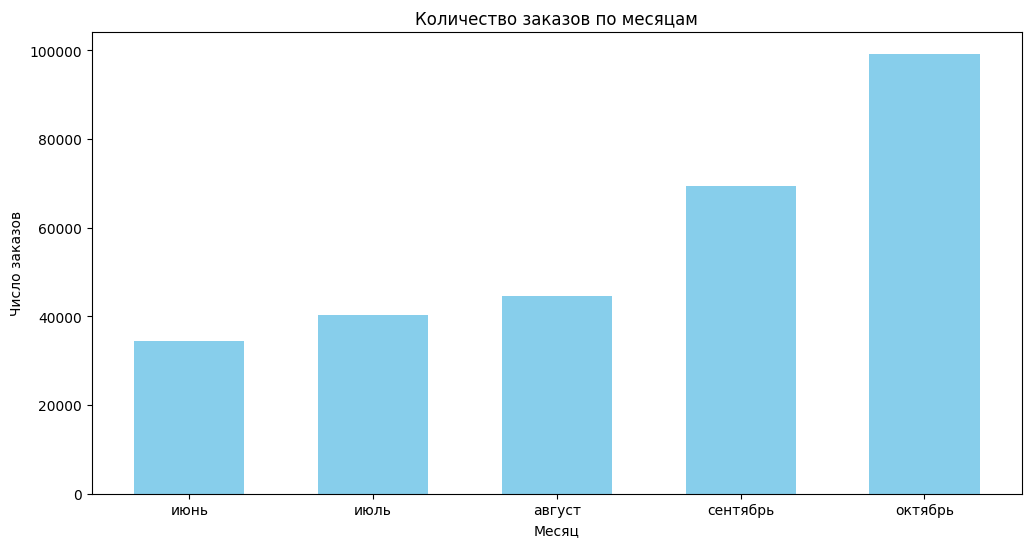

In [75]:
month_orders_count = orders_df.groupby('month')['order_id'].nunique()
plt.figure(figsize=(12, 6))
plt.bar(['июнь', 'июль', 'август', 'сентябрь', 'октябрь'], 
        month_orders_count.values, 
        width=0.6, 
        color='skyblue')
plt.xlabel('Месяц')
plt.ylabel('Число заказов')
plt.title('Количество заказов по месяцам')

event_type_main  выставки     другое   концерты      спорт   стендап  \
season                                                                 
лето             2.028462  27.175182  42.613660   2.523824  5.328072   
осень            1.445011  19.708744  37.187685  11.200024  4.106656   

event_type_main      театр      ёлки  
season                                
лето             20.101591  0.229210  
осень            25.348796  1.003085  


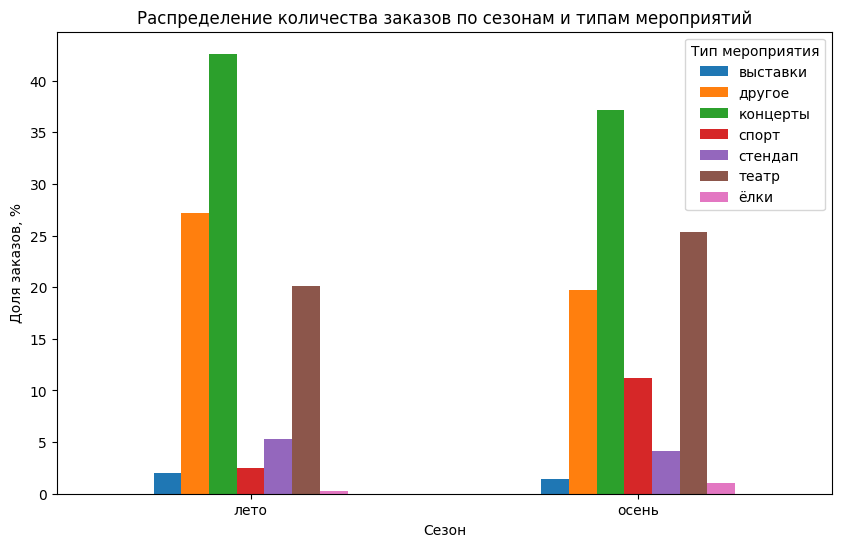

In [107]:
# Количество заказов по сезонам и типам мероприятий
season_event_orders = orders_df.groupby(['season', 'event_type_main'])['order_id'].nunique()

# Доля заказов по типам мероприятий внутри каждого сезона
season_event_orders_share = season_event_orders.unstack(fill_value=0)
season_event_orders_share = season_event_orders_share.div(season_event_orders_share.sum(axis=1), axis=0) * 100

print(season_event_orders_share)

season_event_orders_share.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Сезон')
plt.ylabel('Доля заказов, %')
plt.title('Распределение количества заказов по сезонам и типам мероприятий')
plt.legend(title='Тип мероприятия')
plt.xticks(rotation=0)
plt.show()

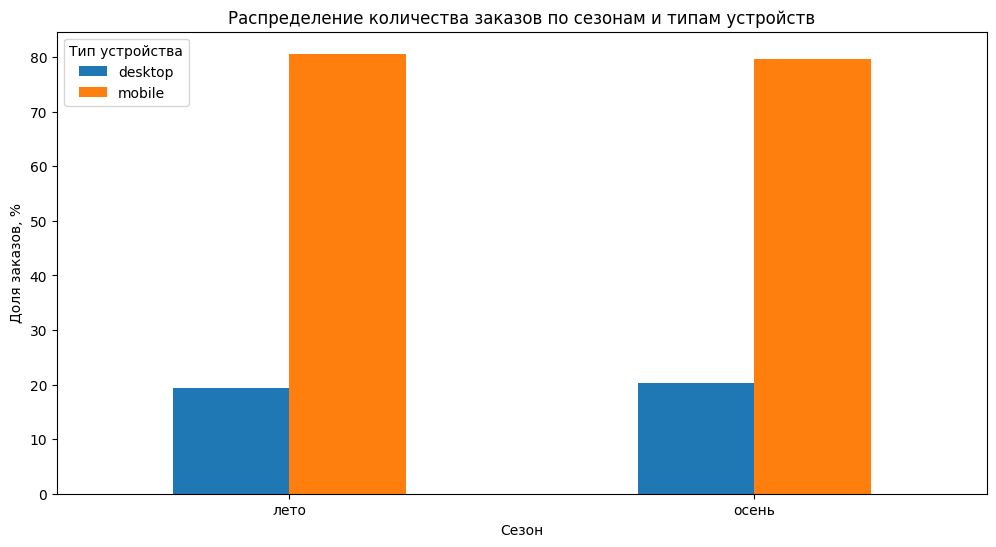

In [77]:
# Количество заказов по сезонам и типам устройств
season_device_orders = orders_df.groupby(['season', 'device_type_canonical'])['order_id'].nunique()

# Доля заказов по типам устройств внутри каждого сезона
season_device_orders_share = season_device_orders.unstack(fill_value=0)
season_device_orders_share = season_device_orders_share.div(season_device_orders_share.sum(axis=1), axis=0) * 100

season_device_orders_share.plot(kind='bar', figsize=(12, 6))
plt.title('Распределение количества заказов по сезонам и типам устройств')
plt.xlabel('Сезон')
plt.ylabel('Доля заказов, %')
plt.legend(title='Тип устройства')
plt.xticks(rotation=0)
plt.show()

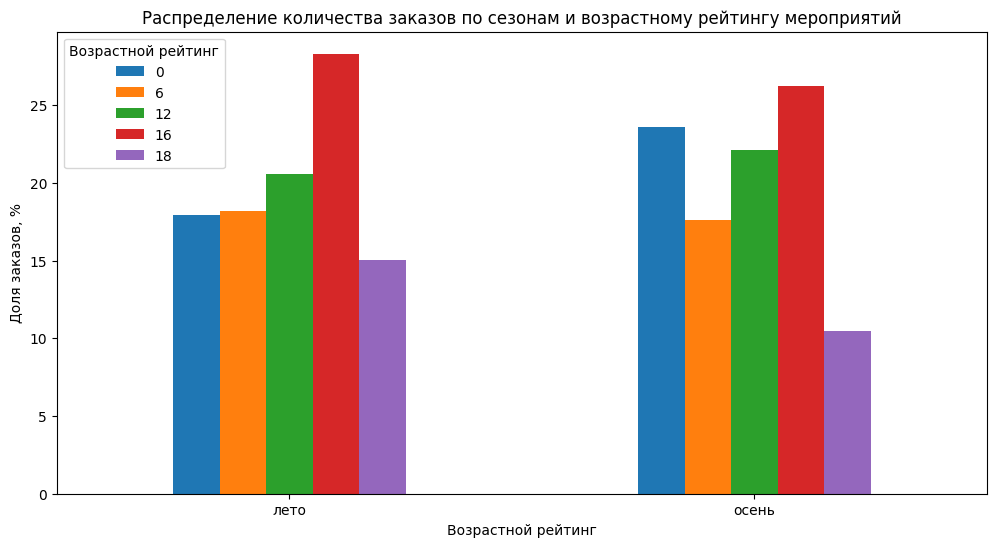

In [78]:
# Количество заказов по сезону и возрастному рейтингу
season_age_orders = orders_df.groupby(['season', 'age_limit'])['order_id'].nunique()

season_age_orders_share = season_age_orders.unstack(fill_value=0)
season_age_orders_share = season_age_orders_share.div(season_age_orders_share.sum(axis=1), axis=0) * 100

season_age_orders_share.plot(kind='bar', figsize=(12, 6))
plt.title('Распределение количества заказов по сезонам и возрастному рейтингу мероприятий')
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Доля заказов, %')
plt.legend(title='Возрастной рейтинг')
plt.xticks(rotation=0)
plt.show()

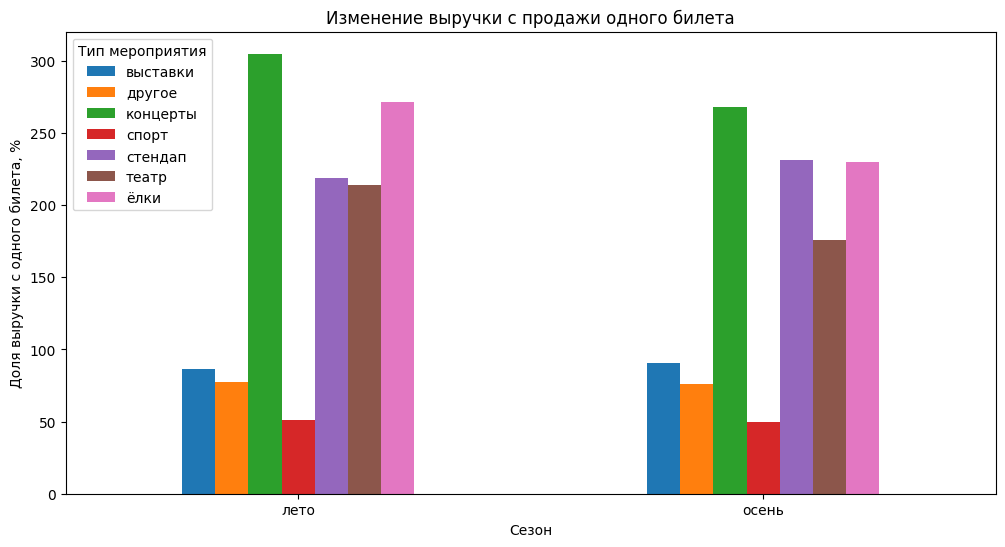

In [89]:
# Изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью
season_event_price = orders_df.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().unstack(fill_value=0)


season_event_price.plot(kind='bar', figsize=(12, 6))
plt.title('Изменение выручки с продажи одного билета')
plt.xlabel('Сезон')
plt.ylabel('Доля выручки с одного билета, %')
plt.xticks(rotation=0)
plt.legend(title='Тип мероприятия')
plt.show()

In [91]:
season_event_price_change = (
    season_event_price.loc['осень'] /
    season_event_price.loc['лето'] - 1
) * 100
season_event_price_change

event_type_main
выставки     4.845634
другое      -1.707279
концерты   -12.021130
спорт       -1.560421
стендап      5.769255
театр      -17.816232
ёлки       -15.418205
dtype: float64

**Вывод**: количество заказов от июня к октябрю уверенно растёт, причём с наступлением сентября прирост усиливается. В разрезе типов мероприятий наиболее заметные изменения наблюдаются для спортивных мероприятий: заказы на них увеличились на 9%. Доля концертов упала с 42.6% до 37.2%, а театров повысилась с 20.1% до 25.3%. Подавляющее большинство пользователей используют мобильные устройства для покупки билетов (80%) и сезон не влияет на это. Осенью сокращается доля проданных билетов на мероприятия 16+ и 18+ и увеличивается доля мерояприятий 0+. Осенью средняя цена за билет на концерт снизилась на 12%, а в театр на 17.8% по сравнению с летом. Зато повысилась цена на стендап на 5.56%.

### 3.2. Осенняя активность пользователей.

In [28]:
aut_orders_df = orders_df[orders_df['season'] == 'осень']

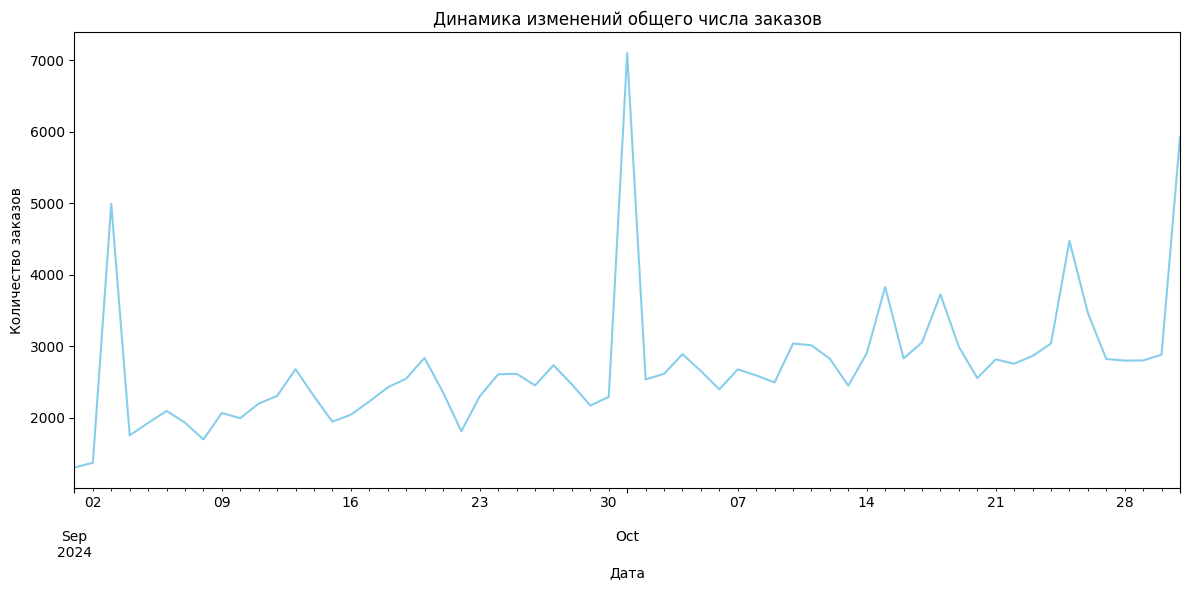

In [29]:
aut_orders_per_day = aut_orders_df.groupby('created_dt_msk')['order_id'].nunique()
aut_orders_per_day.plot(figsize=(12, 6),
                        color='skyblue')
plt.title('Динамика изменений общего числа заказов')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.tight_layout()
plt.show()

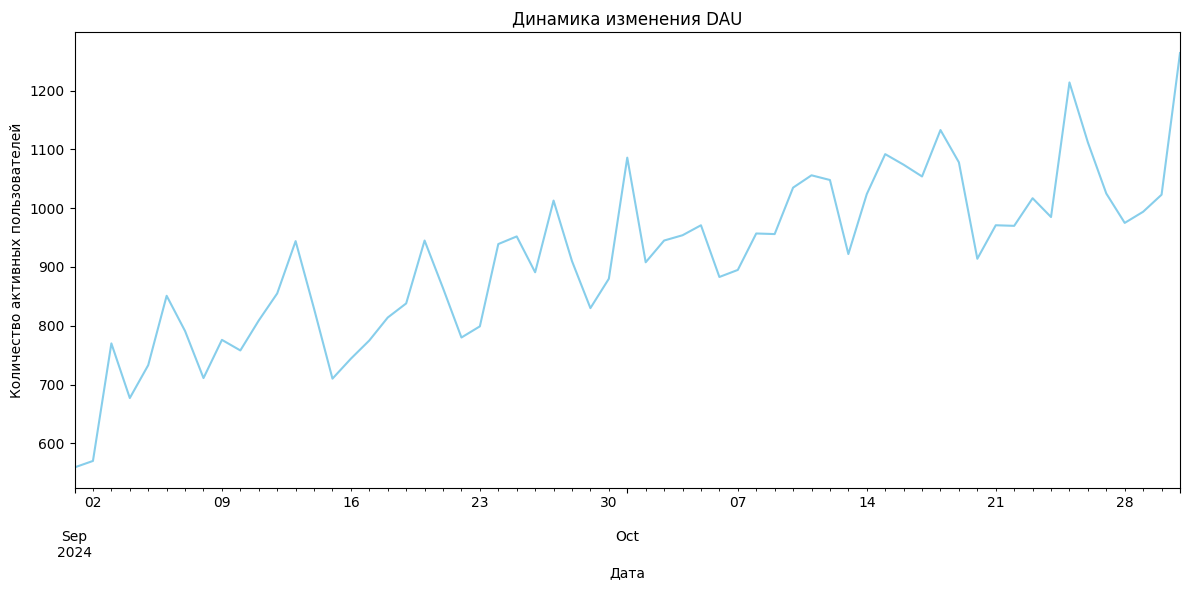

In [30]:
aut_dau = aut_orders_df.groupby('created_dt_msk')['user_id'].nunique()
aut_dau.plot(figsize=(12, 6),
             color='skyblue')
plt.title('Динамика изменения DAU')
plt.xlabel('Дата')
plt.ylabel('Количество активных пользователей')
plt.tight_layout()
plt.show()

C:\Users\Камила\AppData\Local\Temp\ipykernel_46896\1425453876.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aut_orders_per_user = aut_orders_df.groupby('created_dt_msk').apply(lambda x: x['order_id'].nunique() / x['user_id'].nunique())


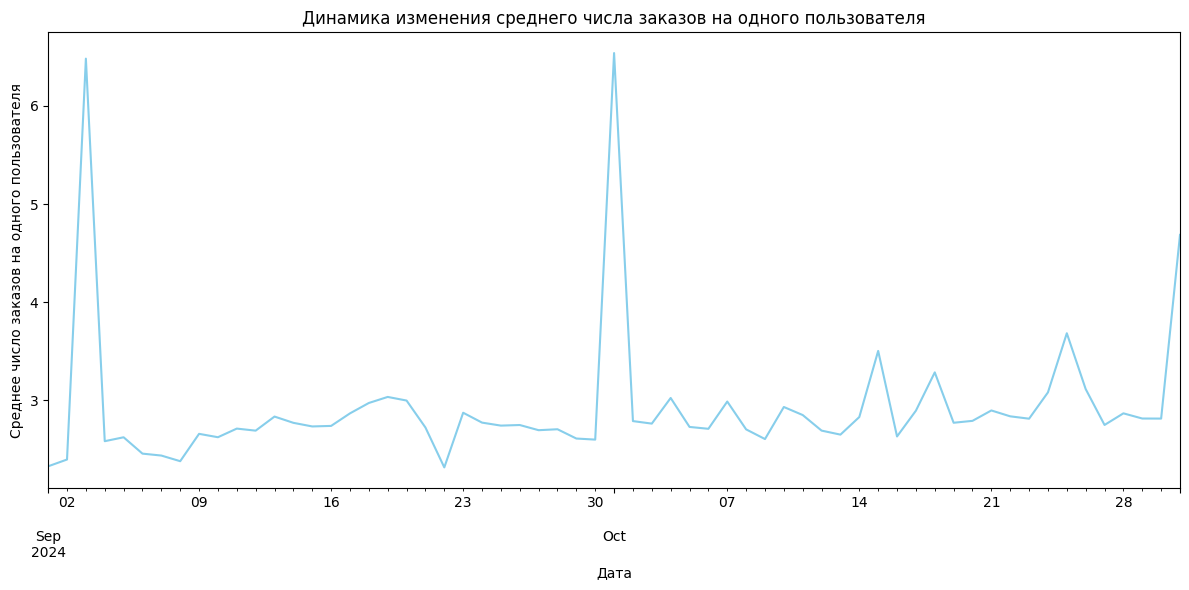

In [31]:
aut_orders_per_user = aut_orders_df.groupby('created_dt_msk').apply(lambda x: x['order_id'].nunique() / x['user_id'].nunique())
aut_orders_per_user.plot(figsize=(12, 6),
                         color='skyblue')
plt.title('Динамика изменения среднего числа заказов на одного пользователя')
plt.xlabel('Дата')
plt.ylabel('Среднее число заказов на одного пользователя')
plt.tight_layout()
plt.show()

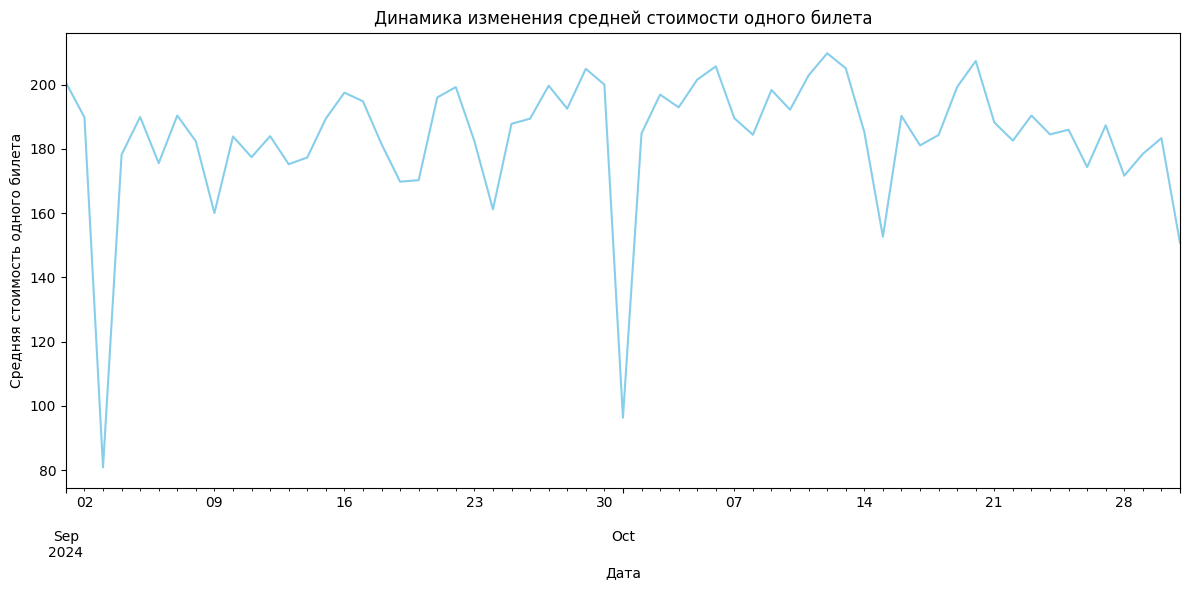

In [32]:
aut_ticket_price = aut_orders_df.groupby('created_dt_msk')['one_ticket_revenue_rub'].mean()
aut_ticket_price.plot(figsize=(12, 6),
                     color='skyblue')
plt.title('Динамика изменения средней стоимости одного билета')
plt.xlabel('Дата')
plt.ylabel('Средняя стоимость одного билета')
plt.tight_layout()
plt.show()

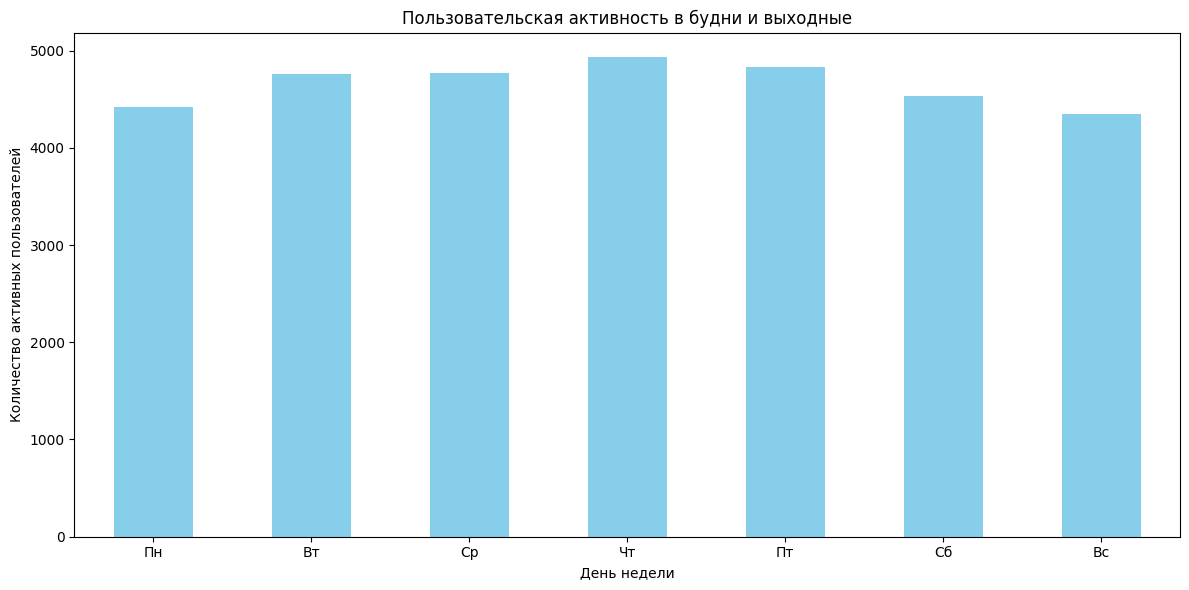

In [94]:
aut_orders_df['day_of_week'] = aut_orders_df['created_dt_msk'].dt.day_of_week
weekday_names = {
    0: 'Пн',
    1: 'Вт',
    2: 'Ср',
    3: 'Чт',
    4: 'Пт',
    5: 'Сб',
    6: 'Вс'
}

weekday_order = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
aut_orders_df['day_of_week'] = aut_orders_df['day_of_week'].map(weekday_names)

aut_week_active = aut_orders_df.groupby('day_of_week')['user_id'].nunique()
aut_week_active = aut_week_active.reindex(weekday_order) 
aut_week_active.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Пользовательская активность в будни и выходные')
plt.xlabel('День недели')
plt.ylabel('Количество активных пользователей')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Вывод**: динамика общего количества заказов по дням сохраняло стабильность (от 2 до 4,5 тысяч в день) за исключением двух пиковых значений - 3 сентября (5 тысяч заказов) и 1 октября (7 тысяч заказов). Количество активных пользователей за день уверенно выросло в 2 раза за период наблюдения (от 600 до 1200 пользователей). Среднее число заказов на пользователя держалось на уровне 2-3 заказов так же за исключением 3 сентября и 1 октября, где это число превысило отметку в 6 заказов. В эти же дни средняя стоимость билета упала до 80 и 100 рублей. Пользователи чаще используют платформу по будним дням, чем в выходные. Максимальная активность достигается в четверг, а минимальная в воскресенье.


### 3.3. Популярные события и партнёры.

In [95]:
# Количество уникальных мероприятий и заказов по регионам
regions = aut_orders_df.groupby('region_name').agg({'event_id':'nunique', 'order_id':'nunique'}).reset_index()
regions = regions.rename(columns={'event_id' : 'events_count', 'order_id' : 'orders_count'})
total_events = regions['events_count'].sum()
total_orders = regions['orders_count'].sum()
regions['events_share'] = regions['events_count'] / total_events * 100.0
regions['orders_share'] = regions['orders_count'] / total_orders * 100.0
regions.sort_values(by='events_count', ascending=False)

,region_name,events_count,orders_count,events_share,orders_share
23,Каменевский регион,3895,45952,24.658141,27.669926
59,Североярская область,2596,20341,16.434540,12.248302
75,Широковская область,799,8598,5.058243,5.177273
56,Светополянский округ,761,4724,4.817675,2.844549
51,Речиновская область,527,3512,3.336288,2.114745
...,...,...,...,...,...
17,Залесский край,4,56,0.025323,0.033720
47,Островогорский округ,4,18,0.025323,0.010839
5,Верхозёрский край,2,11,0.012661,0.006624
55,Светолесский край,2,18,0.012661,0.010839


In [96]:
# Количество уникальных мероприятий, заказов и суммарная выручка по организаторам
partners = aut_orders_df.groupby('service_name').agg({'event_id':'nunique', 'order_id':'nunique', 'revenue_rub':'sum'}).reset_index()
partners = partners.rename(columns={'event_id':'events_count', 'order_id':'orders_count', 'revenue_rub':'total_revenue'})
total_events_partners = aut_orders_df['event_id'].nunique()
total_orders_partners = aut_orders_df['order_id'].nunique()
total_revenue_partners = aut_orders_df['revenue_rub'].sum()
partners['events_share'] = partners['events_count'] / total_events_partners * 100.0
partners['orders_share'] = partners['orders_count'] / total_orders_partners * 100.0
partners['total_revenue_share'] = partners['total_revenue'] / total_revenue_partners * 100.0
partners.sort_values(by='events_count', ascending=False)


,service_name,events_count,orders_count,total_revenue,events_share,orders_share,total_revenue_share
21,Лови билет!,3599,25400,1.010059e+07,22.778481,15.292545,12.670891
3,Билеты без проблем,2830,31823,1.175508e+07,17.911392,19.159632,14.746402
5,Билеты в руки,2460,25259,7.368278e+06,15.569620,15.207653,9.243284
25,Облачко,1401,15342,1.042751e+07,8.867089,9.236938,13.080996
22,Лучшие билеты,1391,12289,1.621018e+06,8.803797,7.398822,2.033519
24,Мой билет,998,19175,1.060259e+07,6.316456,11.544667,13.300637
30,Тебе билет!,852,3691,2.089200e+06,5.392405,2.222236,2.620839
26,Прачечная,727,5682,2.468696e+06,4.601266,3.420954,3.096905
8,Весь в билетах,596,9290,9.121520e+06,3.772152,5.593218,11.442674
34,Яблоко,535,3423,2.697404e+06,3.386076,2.060881,3.383813


**Вывод**: распределение спроса по регионам неоднородно: основная часть мероприятий и заказов сосредоточена в нескольких крупнейших регионах. наибольшее разнообразие мероприятий организовывается в Каменевском регионе (25% от всех мероприятий). Там же самое большое число заказов (28%). Также 16% мероприятий проводится в Североярской области. Самым активным является партнёр "Лови билет!": он проводит 3599 мероприятий (22.7 %) и обрабатывает 25400 заказов (15.2 %). Также в лидерах "Билеты без проблем" и "Билеты в руки" - 2830 (17.9 %) и 2460 (15.6 %) событий соответственно. Расхождение между лидерами по количеству заказов и выручке может быть связано с различиями в средней стоимости билетов и структуре мероприятий.

## 4. Статистический анализ данных.

Гипотезы: 
1. Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
2. Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

Проверим гипотезу 1 с помощью t-теста Уэлча, поскольку он позволяет сравнивать средние при возможном различии дисперсий и не требует предположения об их равенстве.

H0: среднее число заказов на одного пользователя мобильного приложения не отличается от пользователей стационарных устройств.

H1: среднее число заказов на одного пользователя мобильного приложения больше по сравнению с пользователями стационарных устройств.

Уровень значимости = 0.05



In [36]:
device_activity = aut_orders_df.groupby('device_type_canonical').apply(lambda x: x['order_id'].nunique() / x['user_id'].nunique())
device_activity

C:\Users\Камила\AppData\Local\Temp\ipykernel_46896\1810419845.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  device_activity = aut_orders_df.groupby('device_type_canonical').apply(lambda x: x['order_id'].nunique() / x['user_id'].nunique())


device_type_canonical
desktop    6.969546
mobile     9.395758
dtype: float64

In [98]:
mobile_df = aut_orders_df[aut_orders_df['device_type_canonical'] == 'mobile']
desktop_df = aut_orders_df[aut_orders_df['device_type_canonical'] == 'desktop']

In [99]:
mobile_users = set(mobile_df['user_id'])
desktop_users = set(desktop_df['user_id'])

len(mobile_users & desktop_users)

3218

Существует 3218 пользователей, которые использовали для заказа и мобильное устройство, и стационарное. Чтобы не нарушать независимость групп, следует исключить таких пользователей из выборки.

In [103]:
both_users = mobile_users & desktop_users

mobile_df = mobile_df[~mobile_df['user_id'].isin(both_users)]
desktop_df = desktop_df[~desktop_df['user_id'].isin(both_users)]


In [104]:
from scipy.stats import ttest_ind


orders_per_user_mobile = mobile_df.groupby('user_id')['order_id'].nunique()
orders_per_user_desktop = desktop_df.groupby('user_id')['order_id'].nunique()

alpha = 0.05
stat, p_value = ttest_ind(
    orders_per_user_mobile,
    orders_per_user_desktop,
    equal_var=False,
    alternative='greater'
)

if p_value < 0.05:
    print(f"По результатам t-теста Уэлча p-value = {p_value} < 0.05. Нулевая гипотеза отвергается, принимается альтернативная гипотеза.")
else:
    print(f"По результатам t-теста Уэлча p-value = {p_value} > 0.05. Нулевая гипотеза принимается.")


По результатам t-теста Уэлча p-value = 1.0812004217402532e-24 < 0.05. Нулевая гипотеза отвергается, принимается альтернативная гипотеза.


Проверим гипотезу 2 с помощью t-теста Уэлча, поскольку он позволяет сравнивать средние при возможном различии дисперсий и не требует предположения об их равенстве.

H0: среднее время между заказами пользователей мобильных и стационарных устройств не отличается.

H1: среднее время между заказами пользователей мобильных устройств больше, чем пользователей стационарных.

Уровень значимости = 0.05

In [106]:
time_users_mobile = mobile_df.dropna(subset=['days_since_prev']).groupby('user_id')['days_since_prev'].mean()
time_users_desktop = desktop_df.dropna(subset=['days_since_prev']).groupby('user_id')['days_since_prev'].mean()

print('Среднее mobile:', time_users_mobile.mean())
print('Среднее desktop:', time_users_desktop.mean())

alpha=0.05
stat, p_value = ttest_ind(
    time_users_mobile,
    time_users_desktop,
    equal_var=False,
    alternative='greater'
)
if p_value < 0.05:
    print(f"По результатам t-теста Уэлча p-value = {p_value} < 0.05. Нулевая гипотеза отвергается, принимается альтернативная гипотеза.")
else:
    print(f"По результатам t-теста Уэлча p-value = {p_value} > 0.05. Нулевая гипотеза принимается.")


Среднее mobile: 25.174409418990656
Среднее desktop: 31.317535175880284
По результатам t-теста Уэлча p-value = 0.9999991447870686 > 0.05. Нулевая гипотеза принимается.


**Вывод**: по результатам одностороннего t-теста Уэлча для первой гипотезы получено p-value меньше уровня значимости 0.05. Соответственно, нулевая гипотеза отвергается: получены статистически значимые основания считать, что среднее количество заказов на пользователя мобильного устройства выше, чем у пользователя стационарного устройства.

Для второй гипотезы p-value составило 0.99, что значительно выше 0.05. Нулевая гипотеза принимается и тогда среднее время между заказами пользователей мобильных и стационарных устройств статистически не отличается.

## 5. Вывод
В рамках исследования были проанализированы данные о заказе билетов в период с 1 июня по 31 октября 2024 года. Особенное внимание было уделено пользовательской активности осенью. Анализ показал, что осенью пользовательская активность увеличилась по сравнению с летним периодом. Наибольший вклад в спрос вносят билеты на концерт и в театр, при этом структура заказов по категориям мероприятий, устройствам и возрастным ограничениям осенью изменилась минимально по сравнению с летом. Средняя стоимость одного билета по разным типам мероприятий менялась неодинаково: средняя цена за билет на концерт и в театр снизилась, зато повысилась цена на стендап.

Осенняя активность пользователей характеризуется выраженной недельной динамикой. Наблюдаются различия между будними и выходными днями, что может быть полезно учитывать при планировании рекламных активностей и продвижении мероприятий.

Распределение спроса по регионам неоднородно: основная доля заказов сосредоточена в нескольких регионах. Среди билетных партнёров также наблюдается концентрация заказов и выручки у отдельных лидеров. При этом лидер по числу заказов не обязательно является лидером по выручке, поэтому при оценке эффективности партнёров важно учитывать одновременно объём заказов, выручку и среднюю стоимость билета.

Статистический анализ показал статистически значимые различия между средним количеством заказов у пользователей мобильных и стационарных устройств. Однако среднее время между заказами у этих групп статистически не различается. Поэтому в разресе количества заказов, мобильных пользователей можно рассматривать как отдельную группу для продуктового анализа.

В качестве практических рекомендаций стоит обратить внимание на категории мероприятий и регионы с наиболее высокой динамикой спроса, учитывать недельную сезонность при продвижении и отдельно анализировать поведение мобильных пользователей.